In [2]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

path = 'data/raw/M114328462RE.IMG'

with rasterio.open(path) as src:
    print("Width", src.width)
    print("Height", src.height)
    print("Number of bands", src.count)
    print("Data type", src.dtypes[0])
    print("Bounds", src.bounds)
    print("CRS", src.crs)
    print("Transform", src.transform)

    img = src.read(1)

print("Image shape:", img.shape)
print("Pixel value range:", np.min(img), "to", np.max(img))

c:\Users\nicks\miniconda3\envs\lunar\Lib\site-packages\rasterio\__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Width 5064
Height 52224
Number of bands 1
Data type uint8
Bounds BoundingBox(left=0.0, bottom=52224.0, right=5064.0, top=0.0)
CRS None
Transform | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
Image shape: (52224, 5064)
Pixel value range: 12 to 80


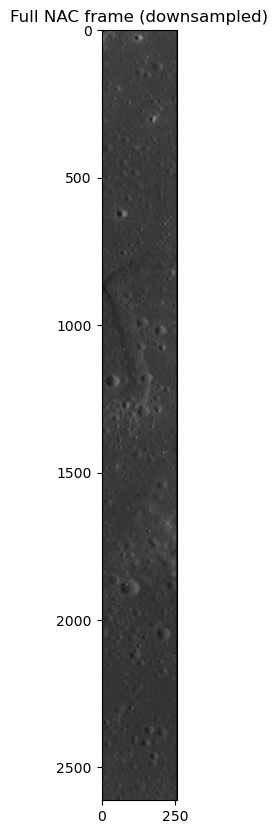

Full image: (52224, 5064), displayed: (2612, 254)


In [3]:
downsampled_img = img[::20, ::20]

plt.figure(figsize=(10, 10))
plt.imshow(downsampled_img, cmap='gray')
plt.title('Full NAC frame (downsampled)')
plt.show()
print(f"Full image: {img.shape}, displayed: {downsampled_img.shape}")


In [ ]:
from rasterio.transform import rowcol

mtp_lat = 8.34
mtp_lon = 33.22

with rasterio.open(path) as src:
    row, col = rowcol(src.transform, mtp_lon, mtp_lat)
    print(f"MTP location in pixel coordinates: row={row}, col={col}")

window_size = 1024
r0, c0 = max(0, row - window_size // 2), max(0, col - window_size // 2)
r1, c1 = r0 + window_size, c0 + window_size

crop = img[r0:r1, c0:c1]

plt.figure(figsize=(10, 10))
plt.imshow(crop, cmap='gray')
plt.title(f'1024px window around MTP at row={row}, col={col}')
plt.show()